# 2. Machine Learning for Regression

In [549]:
import pandas as pd
import numpy as np

# 2.2 Data preparation

In [550]:
df = pd.read_csv('data/data.csv')

In [551]:
# Clean the column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Clean the string columns vales
strings = list(df.dtypes[df.dtypes == 'object'].index)
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [552]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [553]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

# 2.3 Exploratory data analysis

In [554]:
for col in df.columns:
    print(col)
    print(f"First 5 nique values:")
    print(df[col].unique()[:5])
    print(f"Unique values: {df[col].nunique()}")
    print()

make
First 5 nique values:
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
Unique values: 48

model
First 5 nique values:
['1_series_m' '1_series' '100' '124_spider' '190-class']
Unique values: 914

year
First 5 nique values:
[2011 2012 2013 1992 1993]
Unique values: 28

engine_fuel_type
First 5 nique values:
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
Unique values: 10

engine_hp
First 5 nique values:
[335. 300. 230. 320. 172.]
Unique values: 356

engine_cylinders
First 5 nique values:
[ 6.  4.  5.  8. 12.]
Unique values: 9

transmission_type
First 5 nique values:
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
Unique values: 5

driven_wheels
First 5 nique values:
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
Unique values: 4

number_of_doors
First 5 nique values:
[ 2.  4.  3. nan]
Unique values: 3

market_category
First 5 nique values:
['factory_tuner,luxu

In [555]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [556]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

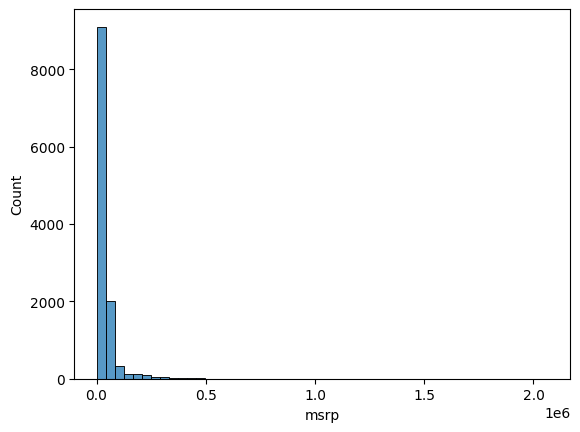

In [557]:
sns.histplot(df.msrp, bins=50)
# This kind of distribution is called LONG TAIL DISTRIBUTION

<Axes: xlabel='msrp', ylabel='Count'>

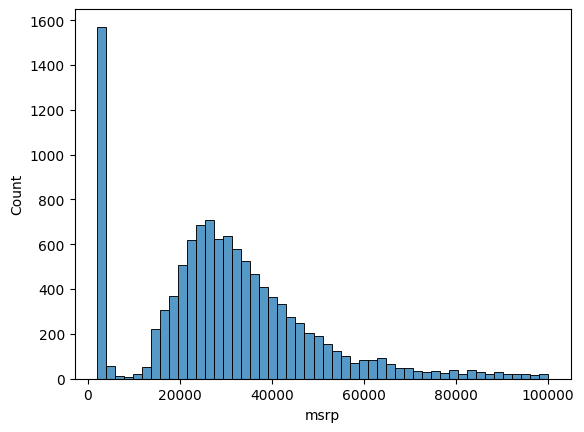

In [558]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [559]:
np.log([1, 10, 1000, 100000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

In [560]:
# Does not exist for value 0
np.log([0, 1, 10, 1000, 100000])

/var/folders/cf/yvx1ty9x60zg9rmfrmvm7pyc0000gn/T/ipykernel_77963/1117793786.py:2: RuntimeWarning: divide by zero encountered in log
  np.log([0, 1, 10, 1000, 100000])


array([       -inf,  0.        ,  2.30258509,  6.90775528, 11.51292546])

In [561]:
# That is why we will add 1 everywhere
# np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])
# And we have a special function for that:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [562]:
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

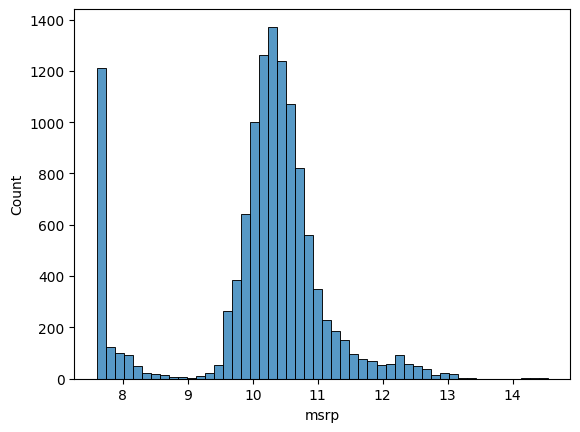

In [563]:
sns.histplot(price_logs, bins=50)
# This distribution is called NORMAL DISTRIBUTION

In [564]:
# Sum all the null values in a data frame
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Setting up the validation framework

In [565]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n, n_val + n_test + n_train

(11914, 11914)

In [566]:
n_val,  n_test, n_train

(2382, 2382, 7150)

In [567]:
df.iloc[[10, 0, 3, 5]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10,bmw,1_series,2013,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39600
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200


In [568]:
df_train = df.iloc[n_test:]
df_val = df.iloc[n_test:n_test+n_val]
df_test = df.iloc[n_test+n_val:]

In [569]:
idx = np.arange(n)

In [570]:
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [571]:
np.random.seed(2)
np.random.shuffle(idx)

In [572]:
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [573]:
df_train = df.iloc[idx[:n_test]]
df_val = df.iloc[idx[n_test:n_test+n_val]]
df_test = df.iloc[idx[n_test+n_val:]]

In [574]:
len(df_train), len(df_val), len(df_test)

(2382, 2382, 7150)

In [575]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [576]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [577]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [578]:
len(y_train), len(y_val), len(y_test)

(2382, 2382, 7150)

# 2.5 Linear Regression

In [579]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [580]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [581]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [582]:
linear_regression(xi)

12.312

In [583]:
float(np.exp(linear_regression(xi)) - 1)

222347.2221101062

In [584]:
float(np.log1p(float(np.exp(linear_regression(xi)) - 1)))

12.312

# 2.6 Linear regression vector form

In [585]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res
    

In [586]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [587]:
linear_regression(xi)

12.312000000000001

In [588]:
w_new = [w0] + w

In [589]:
[1] + [1, 2, 3]

[1, 1, 2, 3]

In [590]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [591]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [592]:
linear_regression(xi)

12.312

In [593]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [594]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [595]:
def linear_regression(X):
    return X.dot(w_new)

In [596]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

# 2.7 Training a linear regression model

In [597]:
def train_linear_regression(X, y):
    pass

In [598]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [599]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [600]:
X = np.column_stack([ones, X])

In [601]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]
y

[10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [602]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)


In [603]:
XTX

array([[9.000000e+00, 2.109000e+03, 2.300000e+02, 4.676000e+03],
       [2.109000e+03, 6.964710e+05, 4.411500e+04, 7.185400e+05],
       [2.300000e+02, 4.411500e+04, 7.146000e+03, 1.188030e+05],
       [4.676000e+03, 7.185400e+05, 1.188030e+05, 6.359986e+06]])

In [604]:
XTX_inv

array([[ 3.30686958e+00, -5.39612291e-03, -6.21325581e-02,
        -6.61016816e-04],
       [-5.39612291e-03,  1.11633857e-05,  8.66973393e-05,
         1.08664195e-06],
       [-6.21325581e-02,  8.66973393e-05,  1.46189255e-03,
         8.57849603e-06],
       [-6.61016816e-04,  1.08664195e-06,  8.57849603e-06,
         3.60215866e-07]])

In [605]:
XTX.dot(XTX_inv).round(1)

array([[ 1., -0.,  0.,  0.],
       [ 0.,  1.,  0., -0.],
       [-0.,  0.,  1.,  0.],
       [-0., -0.,  0.,  1.]])

In [606]:
w_full

array([ 2.58447541e+04, -1.60890647e+01, -1.99472549e+02, -1.22802883e+00])

In [607]:
w0 = w_full[0]
w = w_full[1:]

w0, w

(np.float64(25844.75405576684),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [608]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    # XTX_inv = np.linalg.inv(XTX)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [609]:
train_linear_regression(X, y)

(np.float64(12922.377029467618),
 array([ 1.29223770e+04, -1.60890647e+01, -1.99472549e+02, -1.22802884e+00]))

# 2.8 Car price baseline model

In [610]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [611]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [612]:
df_train[base].isnull().sum()

engine_hp           16
engine_cylinders     6
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [613]:
df_train[base].fillna(0).isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [614]:
X_train = df_train[base].fillna(0).values
X_train

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02],
       ...,
       [1.970e+02, 4.000e+00, 3.200e+01, 2.600e+01, 5.657e+03],
       [3.020e+02, 6.000e+00, 2.800e+01, 2.000e+01, 6.170e+02],
       [2.100e+02, 6.000e+00, 2.000e+01, 1.600e+01, 1.851e+03]],
      shape=(2382, 5))

In [615]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ...,  9.97399261,
       10.92595647, 10.13701698], shape=(2382,))

In [616]:
w0, w = train_linear_regression(X_train, y_train)

In [617]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

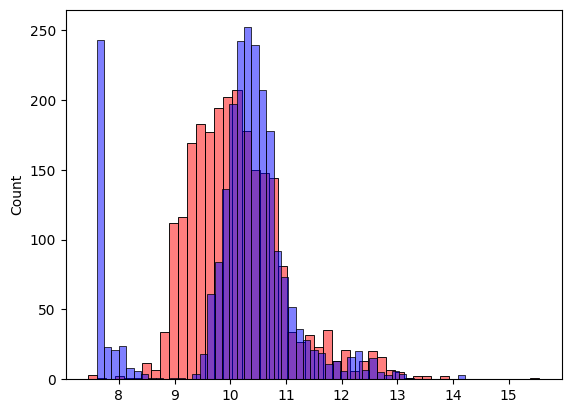

In [618]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

# 2.9 RMSE

In [619]:
def rmse(y, y_pred):
    error = (y - y_pred) ** 2
    mse = error.mean()

    return np.sqrt(mse)

In [620]:
rmse(y_train, y_pred)

np.float64(0.7368944964642169)

# 2.10 Validating the model

In [621]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)

In [622]:
def prepare_X(df):
    df_num = df_train[base]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [623]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)


np.float64(1.4213148292682654)

# 2.11 Simple feature engineering

In [624]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
2377     2
2378     2
2379     1
2380     1
2381     8
Name: year, Length: 2382, dtype: int64

In [625]:
def prepare_X(df):
    df = df.copy()

    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [626]:
X_train = prepare_X(df_train)

In [627]:
X_train

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02, 1.000e+00],
       ...,
       [1.970e+02, 4.000e+00, 3.200e+01, 2.600e+01, 5.657e+03, 1.000e+00],
       [3.020e+02, 6.000e+00, 2.800e+01, 2.000e+01, 6.170e+02, 1.000e+00],
       [2.100e+02, 6.000e+00, 2.000e+01, 1.600e+01, 1.851e+03, 8.000e+00]],
      shape=(2382, 6))

In [628]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5214096637772253)

<Axes: ylabel='Count'>

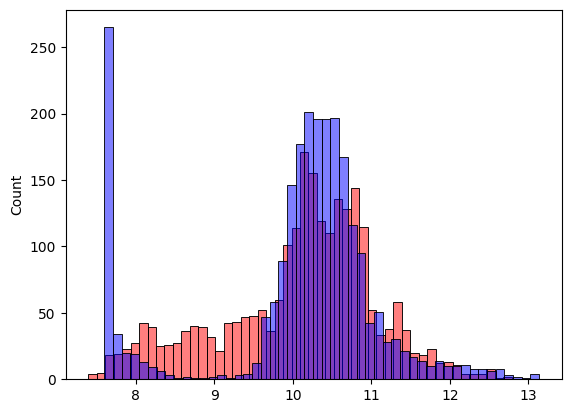

In [629]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

# 2.12 Categorical variables

In [630]:
for v in [2,3,4]:
    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')

In [631]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1,0,0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0,0,1
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0,0,1
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0,1,0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,infiniti,q50,2015,premium_unleaded_(recommended),328.0,6.0,automatic,all_wheel_drive,4.0,"luxury,high-performance",midsize,sedan,27,19,190,0,0,1
2378,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,22,17,1385,1,0,0
2379,ford,fiesta,2016,regular_unleaded,197.0,4.0,manual,front_wheel_drive,4.0,"hatchback,factory_tuner,performance",compact,4dr_hatchback,32,26,5657,0,0,1
2380,mercedes-benz,e-class,2016,premium_unleaded_(required),302.0,6.0,automatic,all_wheel_drive,4.0,"luxury,performance",midsize,sedan,28,20,617,0,0,1


In [632]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [633]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5188138087538711)

In [634]:
makes = list(df.make.value_counts().head().index)

<Axes: ylabel='Count'>

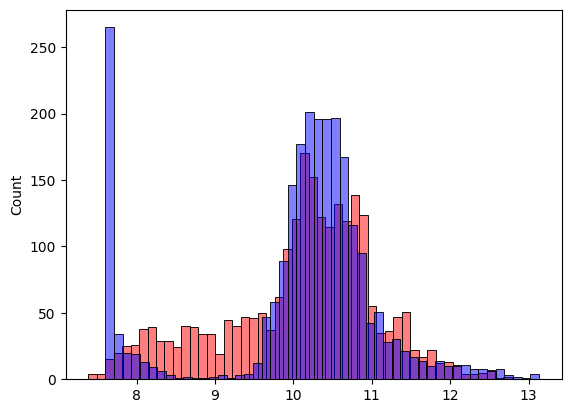

In [635]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

In [636]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    
    for v in makes:
        df['makes_%s' % v] = (df.make == v).astype('int')
        features.append('makes_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [637]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5112339926265321)

<Axes: ylabel='Count'>

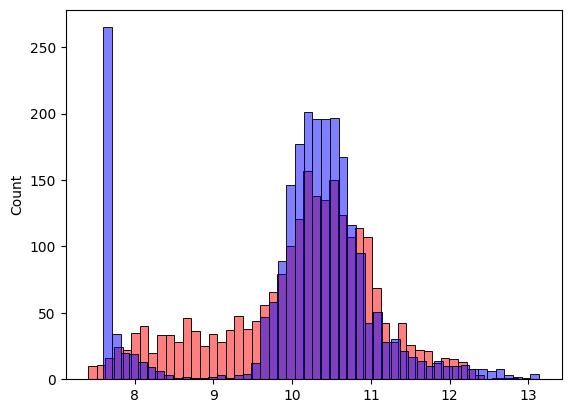

In [638]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

In [639]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
num_doors_2            int64
num_doors_3            int64
num_doors_4            int64
dtype: object

In [644]:
categorical_variables = [
    'make',
    'engine_fuel_type', 
    'transmission_type', 
    'driven_wheels', 
    'market_category', 
    'vehicle_size', 
    'vehicle_style'
    ]

In [645]:
categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

In [652]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [658]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    
    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [659]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.46837437451392466)

<Axes: ylabel='Count'>

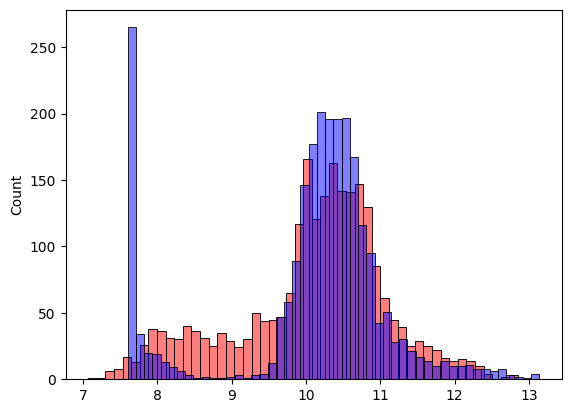

In [660]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

# 2.13 Regularization

In [682]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.0000001]
]

X = np.array(X)
X

array([[4.       , 4.       , 4.       ],
       [3.       , 5.       , 5.       ],
       [5.       , 1.       , 1.       ],
       [5.       , 4.       , 4.       ],
       [7.       , 5.       , 5.       ],
       [4.       , 5.       , 5.0000001]])

In [683]:
y = [1, 2, 3, 1, 2, 3]

In [684]:
XTX = X.T.dot(X)
XTX

array([[140.       , 111.       , 111.0000004],
       [111.       , 108.       , 108.0000005],
       [111.0000004, 108.0000005, 108.000001 ]])

In [685]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 3.93617173e-02, -1.76703045e+05,  1.76703003e+05],
       [-1.76703046e+05,  4.02107113e+13, -4.02107110e+13],
       [ 1.76703004e+05, -4.02107110e+13,  4.02107106e+13]])

In [687]:
XTX_inv.dot(X.T).dot(y)

array([ 3.36741230e-01, -5.04106394e+06,  5.04106425e+06])

In [ ]:
XTX = [
    [1., 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

XTX = np.array(XTX)

In [698]:
np.linalg.inv(XTX)

array([[-3.33333367e-01,  3.33333350e-01,  3.33333350e-01],
       [ 3.33333350e-01,  4.99999991e+06, -5.00000008e+06],
       [ 3.33333350e-01, -5.00000008e+06,  4.99999991e+06]])

In [702]:
XTX = XTX + 0.01 * np.eye(3)
XTX

array([[1.0200001, 2.       , 2.       ],
       [2.       , 1.0200001, 1.       ],
       [2.       , 1.       , 1.0200001]])

In [703]:
np.linalg.inv(XTX)

array([[ -0.34009028,   0.33672303,   0.33672303],
       [  0.33672303,  24.91401062, -25.08573938],
       [  0.33672303, -25.08573938,  24.91401062]])

In [704]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [708]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4682897237800336)

# 2.14 Tunning the model

In [709]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.01, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score  = rmse(y_val, y_pred)

    print(r, w0, score)

0.0 1.8979289482528228e+16 101.14859214303078
1e-05 6.856086257858601 0.4683742737171806
0.0001 7.0314946946765104 0.4683734767560367
0.001 7.017460224544519 0.4683654242087435
0.01 6.9741628529168365 0.4682897237800336
1 5.284197697588919 0.47090267078948694
10 3.3126108874234115 0.5134456119896356


In [710]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4683654242087435)

# 2.15 Using the model

In [ ]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
df_full_train

In [720]:
X_full_train = prepare_X(df_full_train)
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [150.,   6.,  17., ...,   0.,   0.,   0.],
       [268.,   4.,  25., ...,   0.,   0.,   0.],
       [285.,   8.,  17., ...,   0.,   0.,   0.]], shape=(4764, 41))

In [721]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ...,  7.79317435,
       10.29876764, 10.29404205], shape=(4764,))

In [729]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [730]:
w

array([ 1.66863063e-03,  9.78741790e-02, -3.70519916e-02,  1.43036762e-02,
       -4.73558051e-05, -1.02159030e-01, -1.23611989e+00, -1.37192009e+00,
       -1.06574186e+00, -1.78739347e-02,  1.19468188e-01,  2.56483319e-02,
       -1.44648274e-01, -9.93974691e-02, -4.33041936e-01,  9.59644452e-02,
       -2.93893699e-01, -4.95539973e-01,  1.02294136e-01,  1.14243951e+00,
        1.00184049e+00,  1.18522257e+00,  2.90051199e+00,  6.15480384e-01,
        1.80251284e+00,  1.67151828e+00,  1.73845773e+00,  1.63277414e+00,
       -5.12872299e-02,  3.24932172e-02, -5.33544719e-02, -1.10380607e-02,
        7.12998726e-02,  2.36494813e+00,  2.25434272e+00,  2.22593032e+00,
        3.98602444e-02,  2.78331980e-02,  2.25476441e-01,  3.86059014e-01,
       -1.34527828e-01])

In [731]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score  = rmse(y_test, y_pred)
score

np.float64(0.4740684957215826)

In [734]:
car = df_test.iloc[20].to_dict()
car

{'make': 'lincoln',
 'model': 'mark_viii',
 'year': 1996,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 280.0,
 'engine_cylinders': 8.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'rear_wheel_drive',
 'number_of_doors': 2.0,
 'market_category': 'luxury',
 'vehicle_size': 'large',
 'vehicle_style': 'coupe',
 'highway_mpg': 24,
 'city_mpg': 16,
 'popularity': 61}

In [735]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,lincoln,mark_viii,1996,regular_unleaded,280.0,8.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,24,16,61


In [738]:
X_small = prepare_X(df_small)
X_small

array([[280.,   8.,  24.,  16.,  61.,  21.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.]])

In [740]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(8.829596838205193)

In [741]:
np.expm1(y_pred)

np.float64(6832.5312414690225)

In [743]:
np.expm1(y_test[20])

np.float64(2000.0)

# 2.16 Next steps
- We included only 5 top features. What happens if we include 10?

Other projects:
- Predict the price of a house - e.g. boston dataset
- https://archive.ics.uci.edu/ml/datasets.php?task=reg
- https://archive.ics.uci.edu/ml/datasets/Student+Performance

# 2.17 Summary
- EDA - looking at data, finding missing values
- Target variable distribution - long tail => bell shaped curve
- Validation framework: train/val/test split (helped us detect problems)
- Normal equation - not magic, but math
- Implemented it with numpy
- RMSE to validate our model
- Feature engineering: age, categorical features
- Regularization to fight numerical instability